# Timestamp-based $g^{(2)}$ basics

This notebook isolates the ideal timestamp-based HBT measurement without SPAD non-idealities. The main controls are `average_count_rate` and `target_pairs_per_bin`, so you can explore how finite photon statistics make the timestamp estimate noisy compared with the ideal intensity-based $g^{(2)}$.

## Workflow

1. Build a locally flat stellar PSD and an optical filter shape.
2. Draw a thermal electric-field realization from the normalized detected PSD shape.
3. Choose a per-detector mean count rate, then compute the exposure needed to reach the target accidental pairs per `g2` bin.
4. Sample two independent timestamp streams from the same fluctuating thermal intensity.
5. Compare the timestamp-based $g^{(2)}(\tau)$ estimate with the ideal intensity autocorrelation.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from astropy import units as u
from astropy.constants import c

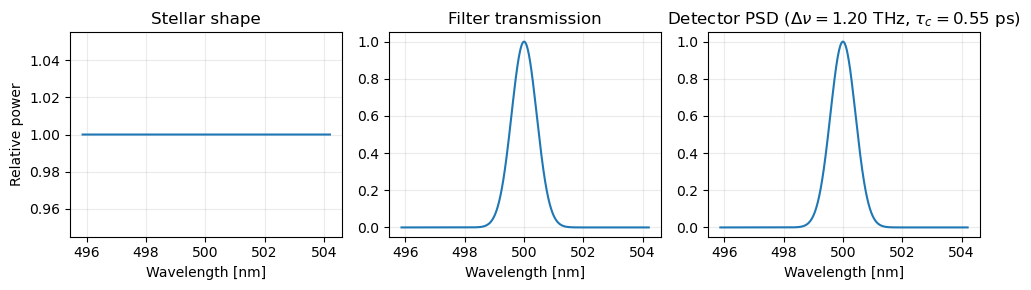

In [20]:
# Duration of one FFT realization. Total integration time is built by
# accumulating many independent realizations, not by increasing n_time.
n_time = 2**14
dt = 0.1 * u.ps
total_time = (n_time * dt).to(u.ns)
chunk_time = n_time * dt

# Central wavelength and filter width
lambda_center = 500.0 * u.nm
fwhm_lambda = 1 * u.nm
sigma_lambda = fwhm_lambda / 2.355
fwhm_nu = (c * fwhm_lambda / lambda_center**2).to(u.THz)

# Convert wavelength to frequency grid for FFT and corresponding wavelength grid
nu_center = (c / lambda_center).to('THz')
nu_offset = np.fft.fftshift(np.fft.fftfreq(n_time, d=dt))
nu_grid = nu_center + nu_offset
lambda_grid = (c / nu_grid).to('nm')

# Filter transmission function in wavelengths
filter_transmission = np.exp(-0.5 * ((lambda_grid - lambda_center) / sigma_lambda)**2)
filter_transmission /= np.max(filter_transmission)

# Flat star-psd could later be upgraded
# Detector PSD is a normalized coherence shape, defined here in wavelength space.
psd_star = np.ones(lambda_grid.shape)
psd_detector = psd_star * filter_transmission

# Coherence time implied by the detector PSD:
# tau_c = ∫S(ν)^2 dν / (∫S(ν)dν)^2
delta_nu = np.abs(np.mean(np.diff(nu_grid)))
tau_c_truth = (
    np.sum(psd_detector**2) * delta_nu
    / (np.sum(psd_detector) * delta_nu)**2
).to(u.ps)

# Reverse index sorting as fft frequency grid is opposite to lambda 
idx = np.argsort(lambda_grid)
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True)
axes[0].plot(lambda_grid[idx], psd_star[idx])
axes[0].set(title="Stellar shape", ylabel="Relative power")
axes[1].plot(lambda_grid[idx], filter_transmission[idx])
axes[1].set(title="Filter transmission")
axes[2].plot(lambda_grid[idx], psd_detector[idx])
axes[2].set_title(
    rf"Detector PSD ($\Delta\nu={fwhm_nu.to_value(u.THz):.2f}$ THz, "
    rf"$\tau_c={tau_c_truth.to_value(u.ps):.2f}$ ps)"
)
for ax in axes:
    ax.set_xlabel("Wavelength [nm]")
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

Simulation duration : 1.64 ns
Average count rate  : 1.00e+11 1 / s
Mean intensity      : 0.125
Peak intensity      : 1.353
Mean count_rate     : 1.00e+11 1 / s
Peak count_rate     : 1.08e+12 1 / s


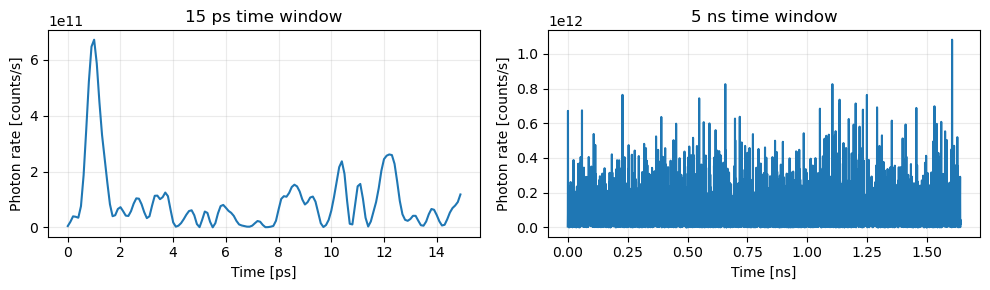

In [21]:
def sample_electric_field_from_psd(psd_shape, rng):
    """Draw a complex Gaussian thermal electric field from a normalized PSD."""
    
    n_samples = psd_shape.size
    gaussian_noise = (rng.normal(size=n_samples) + 1j * rng.normal(size=n_samples)) / np.sqrt(2)

    field_frequency = np.sqrt(psd_shape) * gaussian_noise
    field_time = np.fft.ifft(np.fft.ifftshift(field_frequency), norm="ortho")
    
    return field_time, field_frequency
    
def plot_photon_rate(ax, time_grid, count_rate, plot_window):

    if plot_window < 1 * u.ns: time_unit = u.ps
    elif plot_window < 1 * u.us: time_unit = u.ns
    else: time_unit = u.us

    plot_n = int((plot_window / dt).decompose().value)
    ax.plot(time_grid[:plot_n].to_value(time_unit), count_rate[:plot_n].to_value(1 / u.s))
    ax.set_xlabel(f"Time [{time_unit}]")
    ax.set_ylabel("Photon rate [counts/s]")
    ax.set_title(f"{plot_window:g} time window")
    ax.grid(alpha=0.25)

average_count_rate = 1e11 / u.s

# Thermal electric field realization
rng = np.random.default_rng(7)
time_grid = np.arange(n_time) * dt
field_t, field_freq = sample_electric_field_from_psd(psd_detector, rng)

# Instantaneous optical intensity
intensity = np.abs(field_t) ** 2

# Convert normalized intensity fluctuations into a physical photon rate
count_rate = average_count_rate * intensity / intensity.mean()

print(f"Simulation duration : {total_time:.2f}")
print(f"Average count rate  : {average_count_rate:.2e}")
print(f"Mean intensity      : {intensity.mean():.3f}")
print(f"Peak intensity      : {intensity.max():.3f}")
print(f"Mean count_rate     : {count_rate.mean():.2e}")
print(f"Peak count_rate     : {count_rate.max():.2e}")
   
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_photon_rate(axes[0], time_grid, count_rate, 15 * u.ps)
plot_photon_rate(axes[1], time_grid, count_rate, 5 * u.ns)
fig.tight_layout()

In [22]:
# Photon statistics controls.
# average_count_rate is the per-detector mean count rate.
# target_pairs_per_bin is the desired accidental pair count in one g2 histogram bin.
g2_bin_width = 0.1 * u.ps
target_pairs_per_bin = 1000

if dt > g2_bin_width: 
    print(f"Warning: simulation timestep dt={dt} is larger than g2_bin_width={g2_bin_width}; \
    timestamp structure is under-resolved.")

requested_exposure_time = (target_pairs_per_bin / (average_count_rate**2 * g2_bin_width)).to(u.ns)
n_chunks = int(np.ceil((requested_exposure_time / chunk_time).decompose().value))
exposure_time = n_chunks * chunk_time
expected_pairs_per_bin = (average_count_rate**2 * exposure_time * g2_bin_width).decompose()

print(f"Target pairs/bin        : {target_pairs_per_bin:.0f}")
print(f"Requested exposure      : {requested_exposure_time:.2e}")
print(f"Chunks needed           : {n_chunks:,}")
print(f"Simulated exposure      : {exposure_time.to(u.ns):.2e}")
print(f"Expected pairs/bin      : {expected_pairs_per_bin:.1f}")

Target pairs/bin        : 1000
Requested exposure      : 1.00e+03 ns
Chunks needed           : 611
Simulated exposure      : 1.00e+03 ns
Expected pairs/bin      : 1001.1


In [23]:
def sample_timestamps_from_rate(rate, dt, rng):
    """
    Sample timestamps from a binned inhomogeneous Poisson process.
    Assumes rate has units of 1/time and dt has the corresponding time
    units, so that rate * dt is the expected count per bin.
    """
    counts = rng.poisson(rate * dt)

    nonzero_bins = np.flatnonzero(counts)
    repeated_bins = np.repeat(nonzero_bins, counts[nonzero_bins])
    sub_bin_offsets = rng.uniform(0.0, dt, size=repeated_bins.size)
    
    return np.sort(repeated_bins * dt + sub_bin_offsets)
    

time_unit = u.ps
dt_num = dt.to_value(time_unit)
chunk_time_num = chunk_time.to_value(time_unit)

timestamps = {"spad1": [], "spad2": []}
for chunk_id in tqdm(range(n_chunks)):
    chunk_start = chunk_id * chunk_time_num

    field_t, _ = sample_electric_field_from_psd(psd_detector, rng)
    intensity = np.abs(field_t) ** 2

    count_rate = average_count_rate * intensity / intensity.mean()
    rate_num = count_rate.to_value(1 / time_unit)

    timestamps['spad1'].extend(
        sample_timestamps_from_rate(rate_num, dt_num, rng) + chunk_start
    )
    timestamps['spad2'].extend(
        sample_timestamps_from_rate(rate_num, dt_num, rng) + chunk_start
    )
    
timestamps["spad1"] = np.array(timestamps["spad1"]) * time_unit
timestamps["spad2"] = np.array(timestamps["spad2"]) * time_unit

  0%|          | 0/611 [00:00<?, ?it/s]

The idealized $g^{(2)}$ is computed directly from the continuous intensity realization. Defining the normalized intensity as

$$
I_{\rm norm}(t)=\frac{I(t)}{\langle I\rangle},
$$

the autocorrelation is

$$
g^{(2)}(\tau)
=
\langle I_{\rm norm}(t) I_{\rm norm}(t+\tau)\rangle
=
\mathcal{F}^{-1}\!\left(
\left|\mathcal{F}(I_{\rm norm})\right|^2
\right),
$$

where the Wiener–Khinchin theorem reduces the computation from $O(N^2)$ to $O(N\log N)$.

A second estimate of $g^{(2)}$ is obtained from the simulated photon timestamps by constructing a histogram of arrival-time differences between the two SPAD detectors and normalizing by the expected accidental coincidence rate.

In [24]:
def g2_from_timeseries(intensity, dt):
    """
    Estimate the ideal g² from the simulated intensity before photon
    counting statistics and detector effects.
    """
    intensity_norm = intensity / intensity.mean()
    autocorrelation = np.fft.ifft(np.abs(np.fft.fft(intensity_norm))**2).real / intensity.size
    
    g2 = np.fft.fftshift(autocorrelation)

    # Lag axis corresponding to the fftshifted autocorrelation, with τ=0 at the center.
    tau = (np.arange(intensity.size) - intensity.size // 2) * dt

    return tau, g2

def g2_from_timestamps(timestamps1, timestamps2, exposure_time, bin_width, max_lag):
    """Estimate g² from continuous timestamp pairs using a delay histogram."""

    t1 = timestamps1.to_value(bin_width.unit)
    t2 = timestamps2.to_value(bin_width.unit)

    exposure = exposure_time.to_value(bin_width.unit)
    bin_width_value = bin_width.to_value(bin_width.unit)
    max_lag_value = max_lag.to_value(bin_width.unit)

    edges = np.arange(-max_lag_value, max_lag_value + bin_width_value, bin_width_value)
    bin_centers = edges[:-1] + bin_width_value / 2.0
    counts = np.zeros(edges.size - 1)

    for t in tqdm(t1):
        left = np.searchsorted(t2, t - max_lag_value)
        right = np.searchsorted(t2, t + max_lag_value)
        delays = t2[left:right] - t
        counts += np.histogram(delays, bins=edges)[0]

    tau = 0.5 * (edges[:-1] + edges[1:]) * bin_width.unit

    rate1 = len(t1) / exposure
    rate2 = len(t2) / exposure

    # There is a triangular overlap function that becomes important at short exposure time 
    # Short compared the maximum lag.
    overlap = exposure - np.abs(tau.to_value(bin_width.unit))
    expected_accidentals = rate1 * rate2 * overlap * bin_width_value
    g2 = counts / expected_accidentals
    
    return tau, g2
    
def coherence_time_from_g2_area(tau, g2, peak_window, baseline_window):
    """Estimate coherence time from the area of the g² peak above the measured baseline.
    For idealized g² the baseline is exactly 1, but measured timestamp correlations
    can have a small baseline offset due to finite counting statistics.
    """
    baseline_mask = (
        (np.abs(tau) >= baseline_window[0])
        & (np.abs(tau) <= baseline_window[1])
    )
    baseline = np.mean(g2[baseline_mask])

    peak_mask = np.abs(tau) <= peak_window
    tau_c = np.trapezoid(g2[peak_mask] - baseline, tau[peak_mask])

    return tau_c.to(u.ps), baseline

# Define paraemeters for integration
max_lag = 5 * u.ps
peak_window = 1 * u.ps
baseline_window = (2 * u.ps, 4 * u.ps)

# compute ideal g2 directly from the time series data
tau_ideal, g2_ideal = g2_from_timeseries(intensity, dt)
tau_c_ideal, baseline_ideal = coherence_time_from_g2_area(tau_ideal, g2_ideal, peak_window, baseline_window)

# compute g2 from SPAD1 and SPAD2 arrivals (timestamp data)
tau, g2 = g2_from_timestamps(
    timestamps["spad1"],
    timestamps["spad2"],
    exposure_time=exposure_time,
    bin_width=g2_bin_width,
    max_lag=max_lag,
)
tau_c, baseline = coherence_time_from_g2_area(tau, g2, peak_window, baseline_window)

  0%|          | 0/100395 [00:00<?, ?it/s]

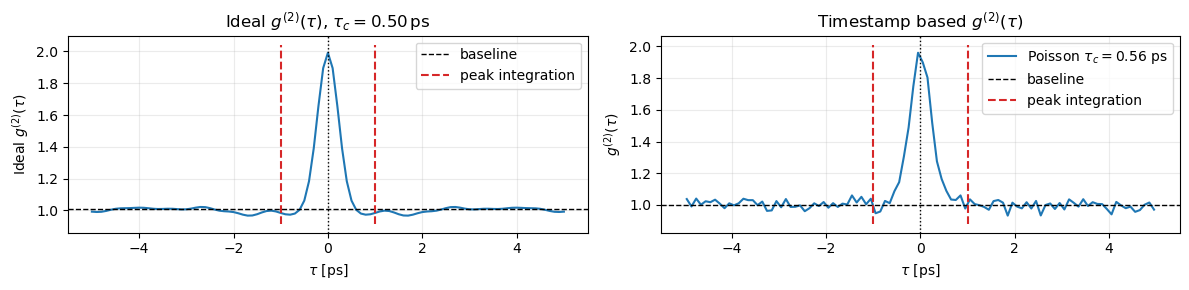

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharex=True)
window_mask = np.abs(tau_ideal) <= max_lag

axes[0].plot(tau_ideal[window_mask].to_value(u.ps), g2_ideal[window_mask])
axes[0].axhline(baseline_ideal, color="k", ls="--", lw=1, label="baseline")
axes[0].axvline(0.0, color="k", ls=":", lw=1)
axes[0].vlines(
    [-peak_window.to_value(u.ps), peak_window.to_value(u.ps)],
    *axes[0].get_ylim(),
    colors="tab:red",
    linestyles="--",
    label="peak integration",
)

axes[0].set_xlabel(r"$\tau$ [ps]")
axes[0].set_ylabel(r"Ideal $g^{(2)}(\tau)$")
axes[0].set_title(rf"Ideal $g^{{(2)}}(\tau)$, $\tau_c={tau_c_ideal.to_value(u.ps):.2f}\,\mathrm{{ps}}$")
axes[0].grid(alpha=0.25)
axes[0].legend()

# Timestamp g2
axes[1].plot(tau.to_value(u.ps), g2, label=rf"Poisson $\tau_c={tau_c.to_value(u.ps):.2f}$ ps")
axes[1].axhline(baseline, color="k", ls="--", lw=1, label="baseline")
axes[1].axvline(0.0, color="k", ls=":", lw=1)
axes[1].vlines(
    [-peak_window.to_value(u.ps), peak_window.to_value(u.ps)],
    *axes[1].get_ylim(),
    colors="tab:red",
    linestyles="--",
    label="peak integration",
)
axes[1].set_xlabel(r"$\tau$ [ps]")
axes[1].set_ylabel(r"$g^{(2)}(\tau)$")
axes[1].set_title(r"Timestamp based $g^{(2)}(\tau)$")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()